In [1]:
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import GaiaData
from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample
from ugdatalab.plotters.bayesian import plot_trace, plot_corner

from plotters import _savefig, plot_period_color_comparison

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
def build_pc_arrays(data):
    """Return (x_centered, bp_rp, sigma_color) for a period-color fit."""
    log_p = np.log10(data["rrlyrae_representative_period"])
    bp_rp = np.array(data["bp_rp"])
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"])
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"])
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    return log_p - np.mean(log_p), bp_rp, sigma_color

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


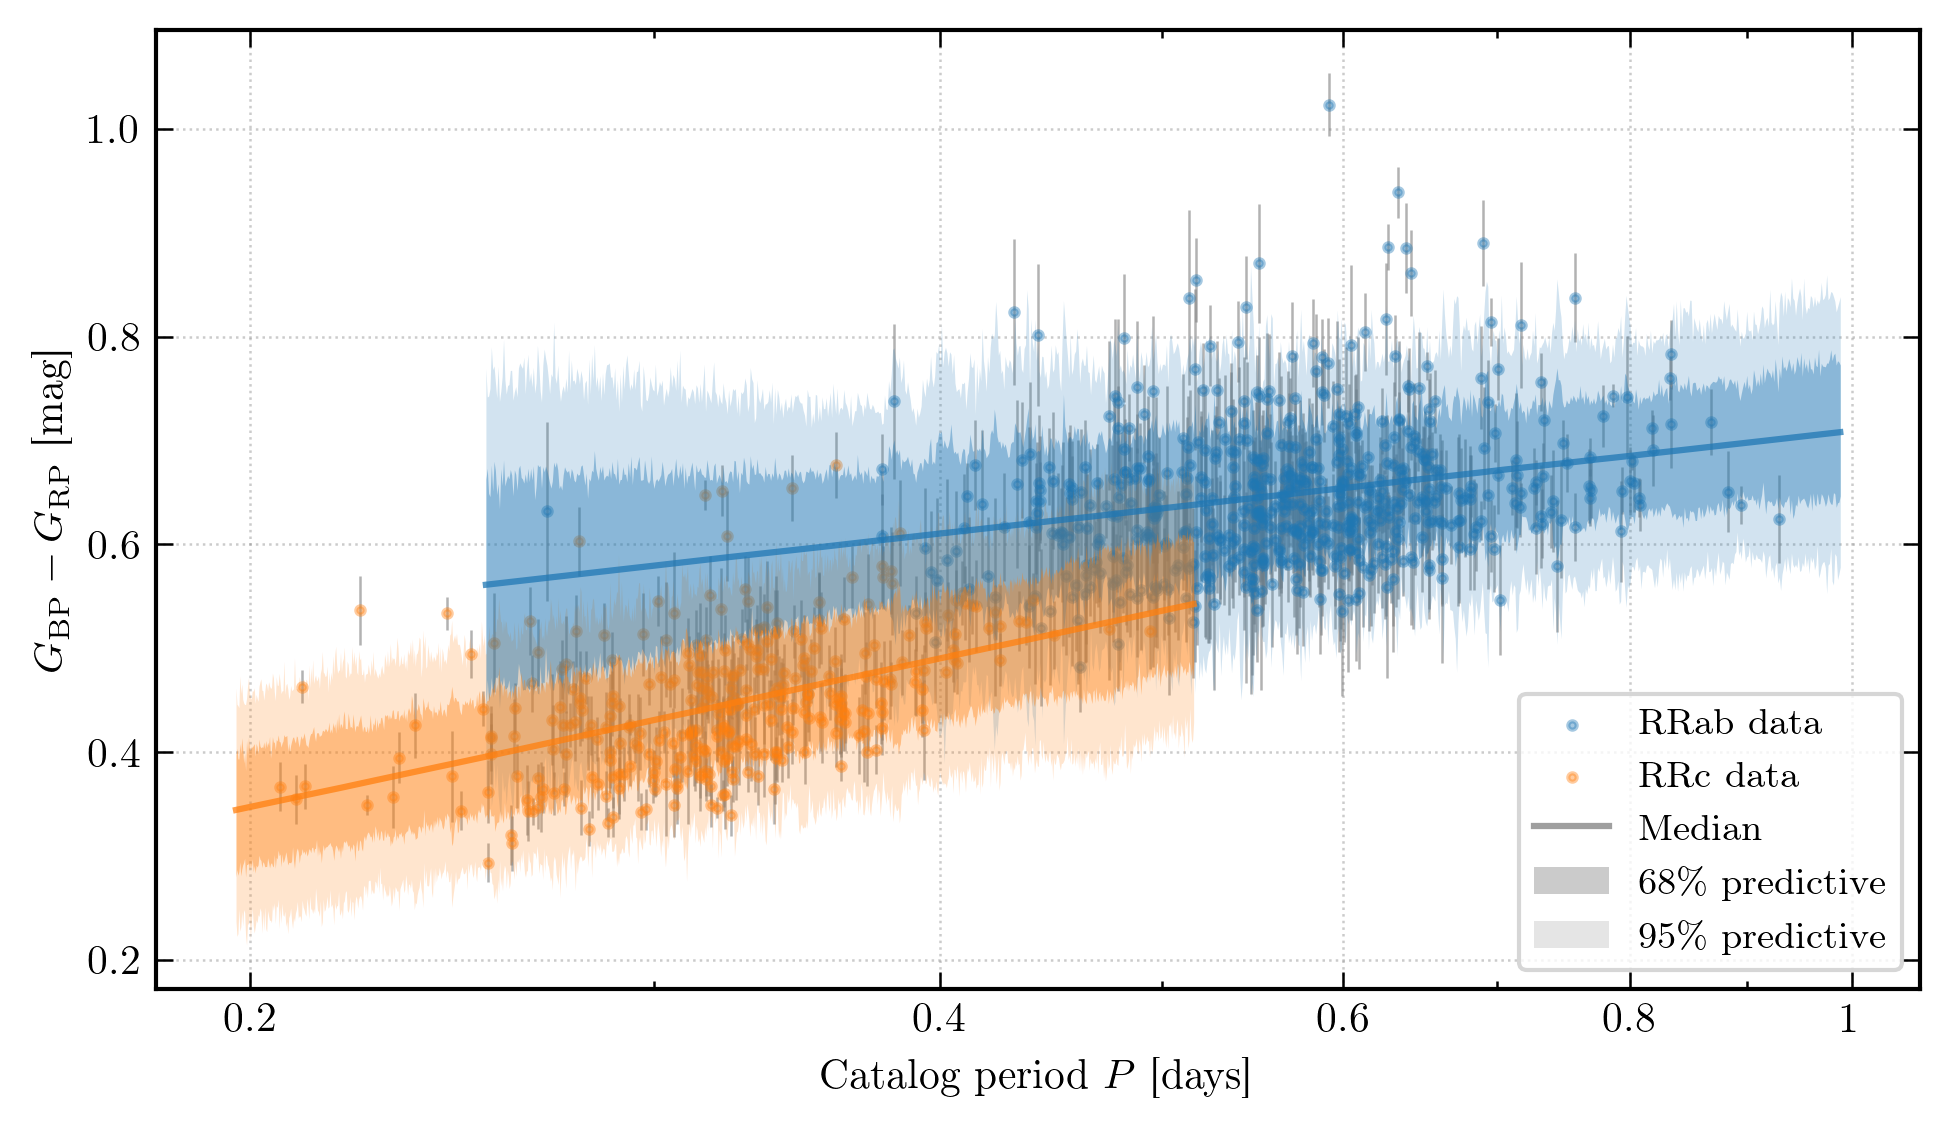

In [3]:
data = np.load(Path("rrlyrae_calibration_sample.npz"), allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_data = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_data = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrab_data)))
rrc_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrc_data)))

ax = plot_period_color_comparison(
    rrab_pc_result, rrc_pc_result,
    float(np.mean(np.log10(rrab_data["rrlyrae_representative_period"]))),
    float(np.mean(np.log10(rrc_data["rrlyrae_representative_period"]))),
)
plt.show()